In [1]:
from herbie import Herbie
import pandas as pd, numpy as np, xarray as xr
import matplotlib.pyplot as plt

In [ ]:
ds_ne = s_ds.sel(latitude = slice(50,40), longitude = slice(280, 300))

In [2]:
ds = xr.open_dataset('gfs_2026022200.nc')

sh: 1: getfattr: not found


In [3]:
ds

<xarray.Dataset> Size: 6MB
Dimensions:            (valid_time: 40, latitude: 81, longitude: 81)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 320B 2026-02-22 ... 2026-0...
  * latitude           (latitude) float64 648B 55.0 54.75 54.5 ... 35.25 35.0
  * longitude          (longitude) float64 648B 280.0 280.2 ... 299.8 300.0
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 320B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
    atmosphere         float64 8B ...
Data variables:
    sde                (valid_time, latitude, longitude) float32 1MB ...
    t2m                (valid_time, latitude, longitude) float32 1MB ...
    tp                 (valid_time, latitude, longitude) float32 1MB ...
    tcc                (valid_time, latitude, longitude) float32 1MB ...
    u10                (valid_time, latitude, longitude) float32 1MB ...
    v10                (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-23T17:15 GRIB to CDM+CF via cfgrib-0.9.1...

### Threat Index Example: Skiing Index
- Range: 0 to 10
- 0 = no skiing (mountain is closed)
- 10 = best possible

Best possible conditions:
- temperature bwteeen 20 - 32 F
- less than 50% cloud cover
- wind speed less than 10 m/s
- snow depth more than 25cm (total)

Weighting:
- temperature: 40%
- wind: 20%
- clouds: 10%
- snow depth: 30%

Temperature contribution:
- 0 when T > 50 F
- 1 when 20 <= T <= 32
- 0 when T < 0
- function slope from 0 - 20 and 32 - 50



Funtion for temp distribution

y = 0 {x < 0}

y = (1 - ((20 - x)/20)^2) {0 <= x < 20}

y = 1 {20 <= x <= 32}

y = (1 - ((x - 32)/18)^2) {32 < x <= 50}

y = 0 {x > 50}

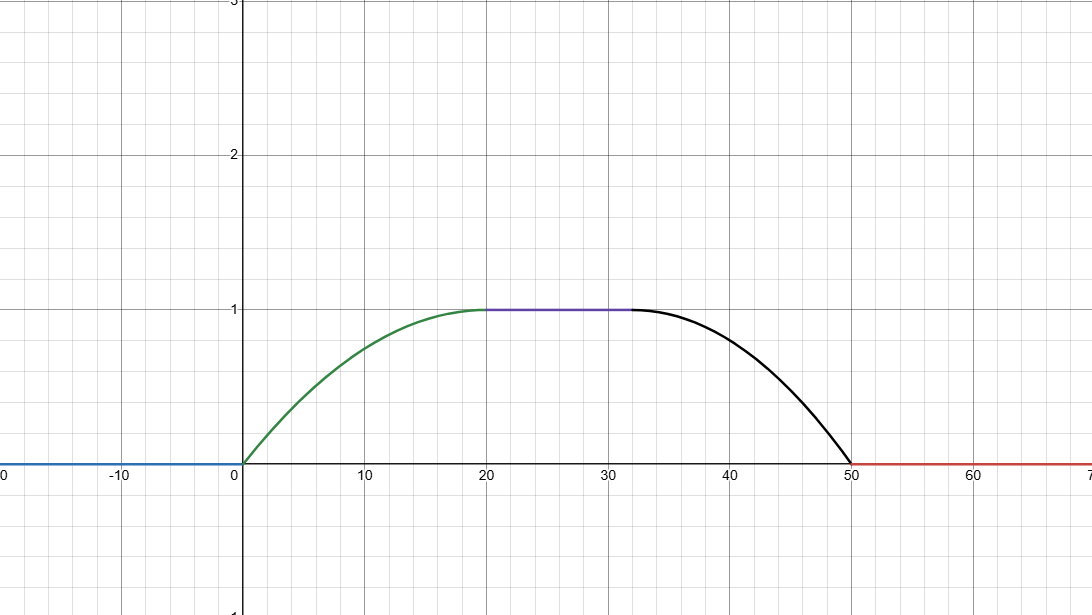

snow depth

y = 0 {x < 25}

y = ((1/500)(x - 25)) {25 <= x < 500}

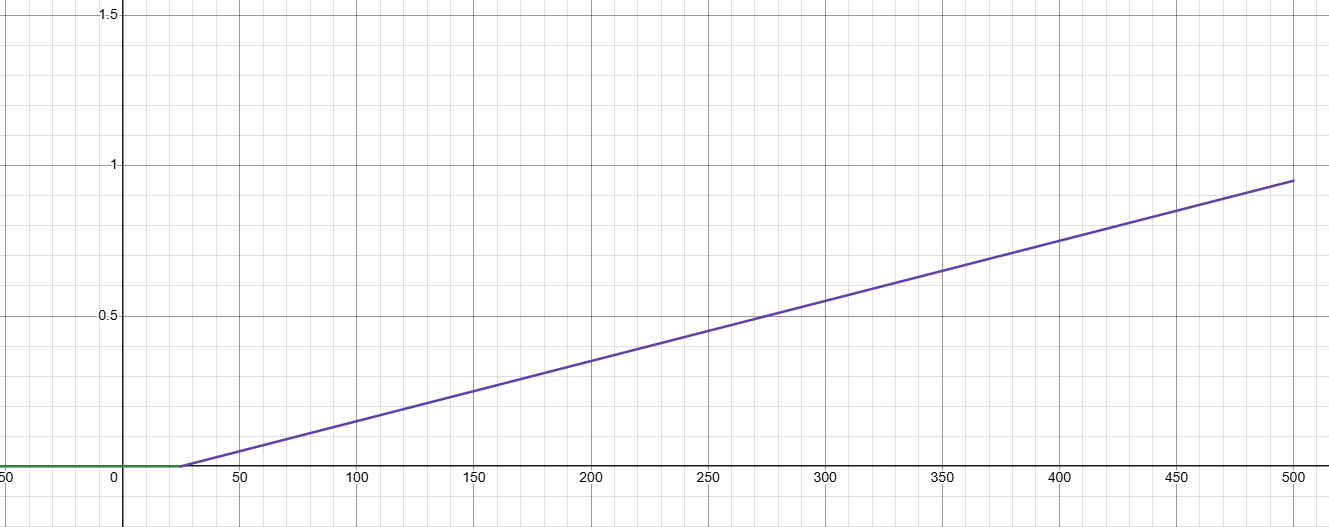

cloud cover

y = (0.01x + 0.5){0 ≤ x ≤ 50}

y = (-0.01x + 1.5){50 ≤ x ≤ 100}

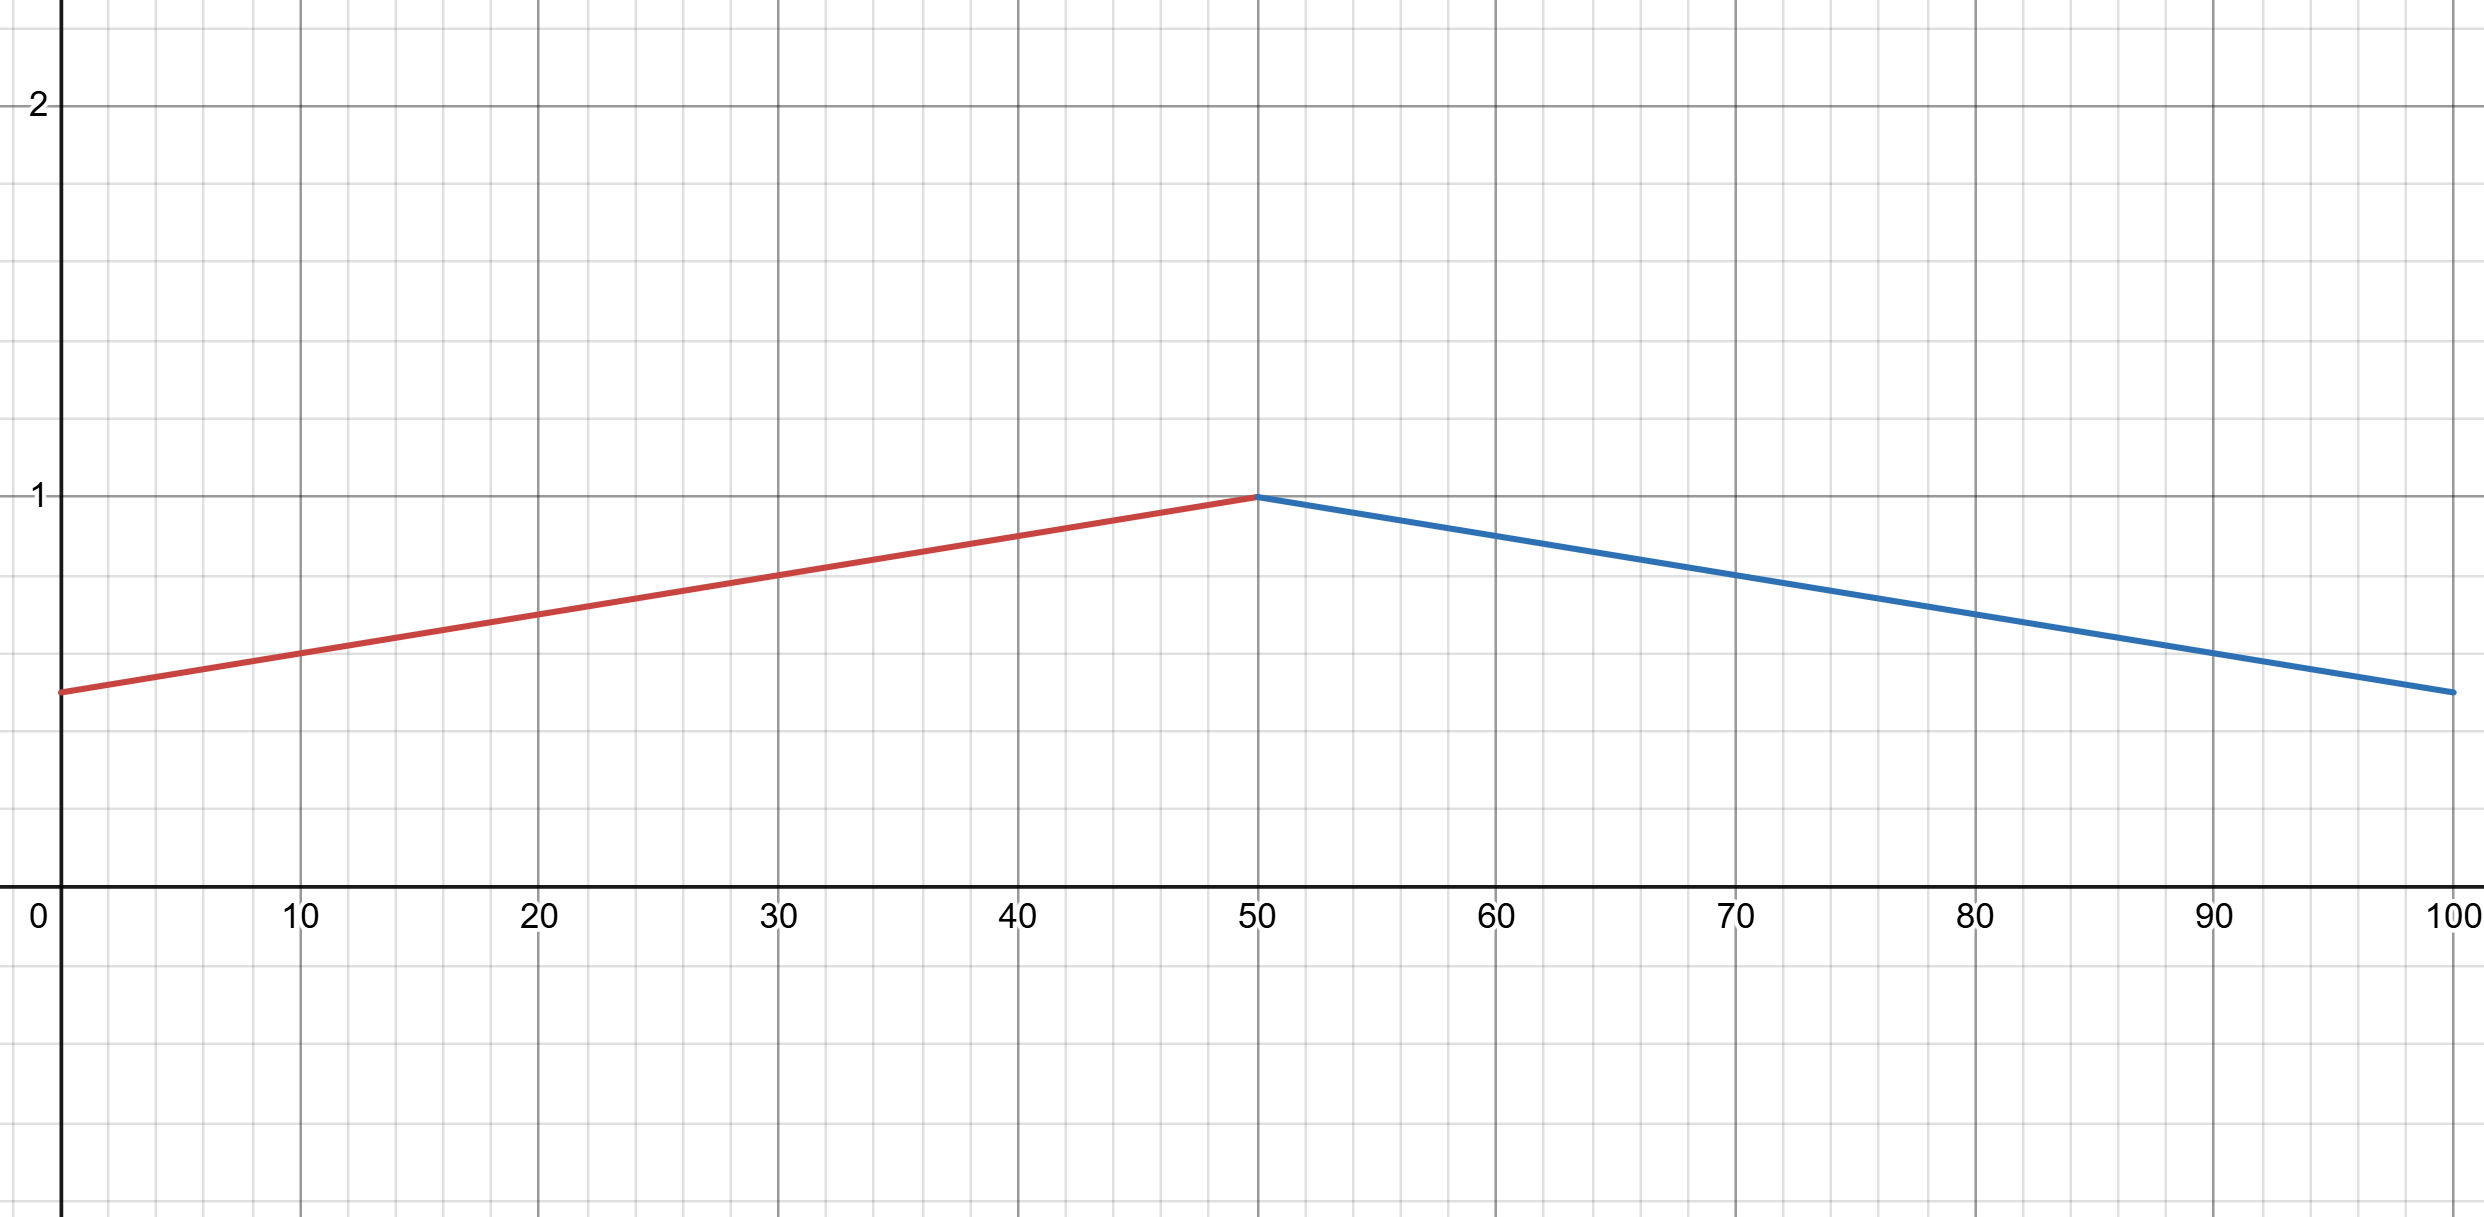

In [ ]:
wind speed

In [ ]:
temp_f = (ds['t2m'].values - 273.15)*(9/5) + 32

In [ ]:
#Total Cloud Cover
tcc_contribution = np.zeros_like(tcc)

# 0 <= tcc <= 50 : linear increase from 0% to 50%
mask = (tcc >= 0) & (tcc <= 50)
tcc_contribution[mask] = (0.01)(tcc[mask]) + 0.5

# 50 < tcc <= 100 : linear decrease from 50% tp 100%
mask = (tcc > 50)
tcc_contribution[mask] = (-0.01)(tcc[mask]) + 1.5
plt.pcolormesh(np.flipud(tcc_contribution))

In [ ]:
#Snow Depth
sde_contribution = np.zeros_like(sde)

# sde < 25 : contribution = 0
mask = (sde < 25)
sde_contribution[mask] = 0

# 25 <= sde <= 500 : linear increase to 500 (max possible snow depth in northeast)
mask = (sde >= 25) & (sde <= 500)
sde_contribution[mask] = ((1/500)((sde[mask]) - 25))
plt.pcolormesh(np.flipud(sde_contribution))

In [ ]:
fig = plt.figure(figsize = (18, 14))                                       #creating a figure

#first plot                                                                #plotting Precipitation, MSLP, and 1000-500 mb Thickness
precip_cmap = mcolors.ListedColormap(precip_colors)                        #creates the colormap using the precip colors from above
precip_norm = mcolors.BoundaryNorm(precip_levels, len(precip_colors))      #creates discrete color bands at specified thresholds

ax1 = fig.add_subplot(2, 2, 1, projection = ccrs.PlateCarree())            #adding a sub plot in the top left
ax1.set_extent([-130, -60, 20, 55], crs = ccrs.PlateCarree())
ax1.add_feature(cfeature.COASTLINE, linewidth = 0.7)
ax1.add_feature(cfeature.BORDERS, linewidth = 0.7)
ax1.add_feature(cfeature.STATES, linewidth = 0.4)

precip_plot = ax1.contourf(long, lat, total_precip_mm, levels = precip_levels, cmap = precip_cmap, norm = precip_norm, extend = 'both') #plotting the precipitation
cbar_1 = plt.colorbar(precip_plot, ax = ax1, pad = .05, shrink = .9, orientation = 'horizontal') #adding the color bar
cbar_1.set_label('Precipitation (mm)', fontsize = 12)

mslp_levels = np.arange(984, 1040, 4) #mean sea level pressure range, counting by 4
mslp_plot = ax1.contour(long, lat, msl_hPa, levels = mslp_levels, colors = 'black') #plotting the mean sea level pressures
ax1.clabel(mslp_plot, inline = True, fmt = '%d', fontsize = 10) #adding labels to the mslp lines

thick_levels = np.arange(5000, 5900, 60) #thickness levels range, counting by 60
thick_plot = ax1.contour(long, lat, thickness, levels = thick_levels,  colors = 'red', linestyles = '--')#plotting the thickness
thick_540 = ax1.contour(long, lat, thickness, levels = [5400], colors = 'blue', linewidths = 3)#highlighting the 540 line in blue
ax1.clabel(thick_plot, inline = True, fmt = '%d', fontsize = 10)#adding labels to the thickness lines

ax1.set_title('ERA5 Precipitation, MSLP, and 1000-500mb Thickness', fontsize = 18) #adding a sub title


#second plot                                                               #plotting 250 mb Wind Speed and Streamlines
ax2 = fig.add_subplot(2, 2, 2, projection = ccrs.PlateCarree())
ax2.set_extent([-130, -60, 20, 55], crs  =ccrs.PlateCarree())
ax2.add_feature(cfeature.COASTLINE, linewidth = 0.7)
ax2.add_feature(cfeature.BORDERS, linewidth = 0.7)
ax2.add_feature(cfeature.STATES, linewidth = 0.4)

wsp_plot = ax2.contourf(long, lat, wsp, cmap = 'jet', levels = np.linspace(30, 170, 14), extend = 'max')#plotting the windspeeds
cbar_2 = plt.colorbar(wsp_plot, ax = ax2, pad = .05, shrink = .9, orientation = 'horizontal')
cbar_2.set_label('250 mb Wind Speed (kt)', fontsize = 12)
ax2.streamplot(long.values, lat.values, u_250_K, v_250_K, density = 1.5, color = 'black', linewidth = 1, arrowsize = 1) #adding the streamlines

ax2.set_title('ERA5 250mb Wind Speed and Streamlines', fontsize = 18)


#third plot                                                                #plotting 2m Temperature Anomaly
ax3 = fig.add_subplot(2, 2, 3, projection = ccrs.PlateCarree())
ax3.set_extent([-130, -60, 20, 55], crs = ccrs.PlateCarree())
ax3.add_feature(cfeature.COASTLINE, linewidth = 0.7)
ax3.add_feature(cfeature.BORDERS, linewidth = 0.7)
ax3.add_feature(cfeature.STATES, linewidth = 0.4)

temp_anom_plot = ax3.contourf(long, lat, temp_anomaly, levels = np.linspace(-20, 20, 41), extend = 'both', cmap = 'RdBu_r') #plotting the temperature anomaly
cbar_3 = plt.colorbar(temp_anom_plot, ax = ax3, pad = .05, shrink = .9, orientation = 'horizontal')
cbar_3.set_label('2m Temperature Anomaly (°C)', fontsize = 12)

ax3.set_title('2m Temperature Anomaly (ERA5 - NCEP Climatology)', fontsize = 18)


#fourth plot                                                               #plotting Total Column Water Vapor (Precipitable Water)
ax4 = fig.add_subplot(2, 2, 4, projection = ccrs.PlateCarree())
ax4.set_extent([-130, -60, 20, 55], crs = ccrs.PlateCarree())
ax4.add_feature(cfeature.COASTLINE, linewidth = 0.7, edgecolor = 'green')
ax4.add_feature(cfeature.BORDERS, linewidth = 0.7, edgecolor = 'green')
ax4.add_feature(cfeature.STATES, linewidth = 0.4, edgecolor = 'green')

tcwv_plot = ax4.contourf(long, lat, tcwv, cmap = 'grey', levels = np.arange(20,80,1), extend = 'both') #plotting the Total Column Water Vapor
cbar_4 = plt.colorbar(tcwv_plot, ax = ax4, pad = .05, shrink = .9, orientation = 'horizontal')
cbar_4.set_label('Total Column Water Vapor (mm)', fontsize = 12)

ax4.set_title('ERA5 Precipitable Water (TCWV)', fontsize = 18)


plt.tight_layout(rect = [0, 0, 1, 0.95]) #making the layout of the 4 subplots look nicer

fig.suptitle(f'{storm_name} - ERA5 Analysis for {written_date}', fontsize = 24) #adding a title for the whole figure


In [1]:
def basemap():
    fig = plt.figure(figsize = (12,8))
    ax = fig.add_subplots(nrows = 2, ncols = 3, projection = ccrs.PlateCarree())
    
    ax.set_extent([-80,-60,40,50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth = 0.7)
    ax.add_feature(cfeature.STATES, linestyle=':', linewidth = 0.5)
    ax.add_feature(cfeature.BORDERS, linewidth = 0.7)

    gridlines = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = True, linewidth = 0.5, color = 'gray', alpha = 0.5, linestyle = '--')

    return fig, ax



NameError: name 'plt' is not defined

In [ ]:
for i in range(len(date)):
    date_time_str = date[i] + " " + time[i]                                      #in the for loop to combine the date and time strings
    dt_object = datetime.strptime(date_time_str, "%m/%d/%y %H:%M:%S")            #in the for loop converting the string to a python object
    datetime_list.append(np.datetime64(dt_object))                               #in the for loop adding it to the end of the list


the tp is in liquid precip, convert tto snow (10:1)
put into inches and multi by 10

In [2]:
from herbie import Herbie
import pandas as pd, numpy as np, xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import cartopy.crs as ccrs, cartopy.feature as cfeature
from datetime import datetime, timedelta, time, timezone
import xarray as xr
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [3]:
ds = xr.open_dataset('gfs.nc')

sh: 1: getfattr: not found


In [4]:
chosen_hour = 30
s_ds = ds.isel(valid_time = chosen_hour)    #selecting a time in the data set to work with

In [5]:
ds_ne = s_ds.sel(latitude = slice(50,40), longitude = slice(280, 300))   #selecting the northeast of the united states

t2m_f = (ds_ne['t2m'].values-273.15)* (9/5) + 32 #Fahrenheit

tcc = ds_ne['tcc'].values #%

u = ds_ne['u10'].values * 2.23694 
v = ds_ne['v10'].values * 2.23694 
wind = np.sqrt(u**2 + v**2) #mph

sde = ds_ne['sde'].values * 100 #Cm

csnow = ds_ne['csnow'].values #catagorial snow

tp = ds_ne['tp'].values * 2.54 #in inches and changed to snow from liquid using ratio
tp_interval = np.diff(tp, axis=0) #gets the change per time interval for total precip, from chatgpt
tp_interval = np.maximum(tp_interval, 0) 

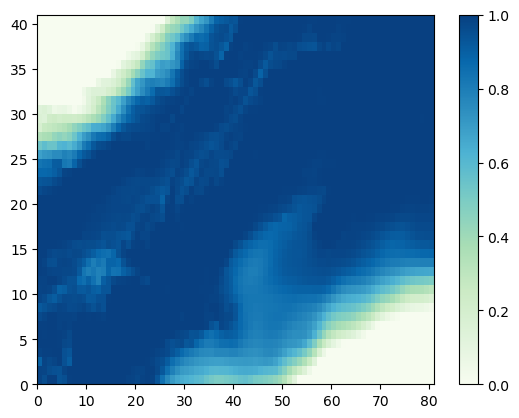

In [13]:
#2 Meter Temperature
t2m_contribution = np.zeros_like(t2m_f)

# 0 <= T < 20 : increase from 0 to 1
mask = (t2m_f >= 0) & (t2m_f < 20)
t2m_contribution[mask] = (1 - ((20 - t2m_f[mask])/20)**2)

# 20 <= T <= 32 : contribution = 1
mask = (t2m_f >= 20) & (t2m_f <= 32)
t2m_contribution[mask] = 1.0

# 32 < T < 50 : decrease from 1 to 0.5
mask = (t2m_f > 32) & (t2m_f < 50)
t2m_contribution[mask] = (1 - ((t2m_f[mask] - 32)/18)**2)

# T >- 50 : contribution = 0
mask = t2m_f >= 50
t2m_contribution[mask] = 0
plt.pcolormesh(np.flipud(t2m_contribution), cmap = 'GnBu')
plt.colorbar()


# You can earn up to 5 bonus points by taking automation one step further:
Add code to your .py script that downloads the most recent complete model run based
on the current time

Save the data and generate the threat index plots as before

Set up a cron job to run the script automatically (e.g., every 6 or 12 hours)


In [ ]:
# get current UTC time
now = datetime.utcnow()

# round DOWN to most recent 6-hour run (00, 06, 12, 18)
cycle_hour = (now.hour // 6) * 6

H = Herbie(f"{now:%Y-%m-%d} {cycle_hour:03d}:00",model="gfs",product="pgrb2.0p25",fxx=range(0, 73, 6))

ds = H.xarray()  # this replaces xr.open_dataset()

In [ ]:
ds.to_netcdf("latest_gfs.nc")

In [ ]:
crontab -e

In [ ]:
0 */6 * * * /usr/local/anaconda3/envs/custom_envs/meteo473_sp26/bin/python /courses/meteo473/sp26/473_sp26_group1/threat_index.py

In [ ]:
OUTPUT_DIR = "/courses/meteo473/sp26/473_sp26_group1/website/images"

In [ ]:
crontab -e

In [ ]:
0 */6 * * * /usr/local/anaconda3/envs/custom_envs/meteo473_sp26/bin/python /courses/meteo473/sp26/473_sp26_group1/threat_index.py